# 29 · Five-model frontier review

This public review summarizes the latest AWS-only diversity/ensemble work after the Qwen3-14B study. It uses **aggregate metrics only**. Raw comments, row-level predictions, exact ensemble weights, adapters, optimizer state, caches, credentials, and full cloud logs remain private.

The retained official Kaggle result remains **0.91808 public / 0.91425 private ROC AUC**. The five-model candidate below is development evidence, not a new leaderboard score.

Loaded public frontier checkpoint: development_candidate_promoted_pending_official_score
Rows: 881 | Policies: 2
PLOTLY_AND_SVG_RENDERED


Figure({    'data': [{'type': 'bar', 'orientation': 'h'}],    'layout': {'title': {'text': 'Five-model frontier: aggregate development evidence'}}})

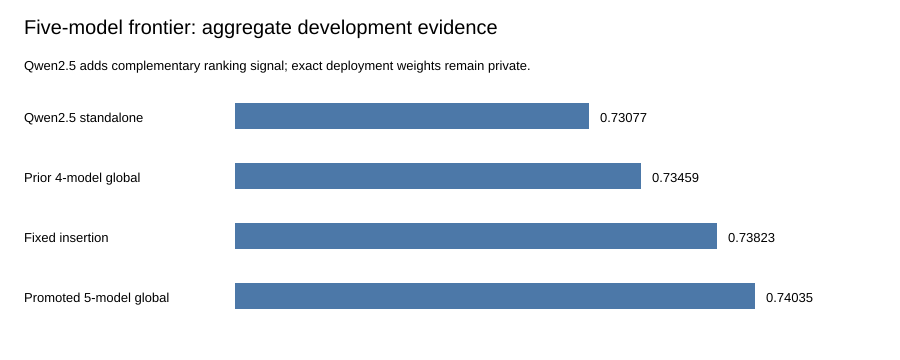

In [1]:
import json
from pathlib import Path
import pandas as pd
import plotly.graph_objects as go
from IPython.display import SVG, display

ROOT = Path.cwd()
record = json.loads((ROOT / 'reports/checkpoints/five_model_frontier.json').read_text())
rows = [
    ('Qwen2.5 standalone', record['full_oof']['qwen25_standalone_macro_auc']),
    ('Prior 4-model global', record['global_deployment_validation']['prior_four_model_global_macro_auc']),
    ('Fixed insertion', record['full_oof']['fixed_insertion_macro_auc']),
    ('Promoted 5-model global', record['global_deployment_validation']['promoted_five_model_global_macro_auc']),
]
frame = pd.DataFrame(rows, columns=['System', 'Policy-macro AUC'])
display(frame.round(6))
fig = go.Figure(go.Bar(x=frame['Policy-macro AUC'], y=frame['System'], orientation='h', text=frame['Policy-macro AUC'].map(lambda x: f'{x:.5f}'), textposition='outside'))
fig.update_layout(template='none', title='Five-model frontier: aggregate development evidence', height=380, margin=dict(l=190, r=70, t=70, b=55), xaxis_title='Policy-macro ROC AUC', yaxis=dict(autorange='reversed'), showlegend=False)
display(fig)
svg = '''<svg xmlns="http://www.w3.org/2000/svg" width="900" height="360">
<rect width="900" height="360" fill="white"/>
<text x="24" y="34" font-size="20" font-family="Arial">Five-model frontier: aggregate development evidence</text>
<text x="24" y="70" font-size="13" font-family="Arial">Qwen2.5 adds complementary ranking signal; exact deployment weights remain private.</text>
<text x="24" y="122" font-size="13" font-family="Arial">Qwen2.5 standalone</text>
<rect x="235" y="103" width="354" height="26" fill="#4C78A8"/><text x="600" y="122" font-size="13" font-family="Arial">0.73077</text>
<text x="24" y="182" font-size="13" font-family="Arial">Prior 4-model global</text>
<rect x="235" y="163" width="406" height="26" fill="#4C78A8"/><text x="652" y="182" font-size="13" font-family="Arial">0.73459</text>
<text x="24" y="242" font-size="13" font-family="Arial">Fixed insertion</text>
<rect x="235" y="223" width="482" height="26" fill="#4C78A8"/><text x="728" y="242" font-size="13" font-family="Arial">0.73823</text>
<text x="24" y="302" font-size="13" font-family="Arial">Promoted 5-model global</text>
<rect x="235" y="283" width="520" height="26" fill="#4C78A8"/><text x="766" y="302" font-size="13" font-family="Arial">0.74035</text>
</svg>'''
display(SVG(svg))
print('Loaded public frontier checkpoint:', record['status'])
print('Rows:', record['development_cohort']['rows'], '| Policies:', record['development_cohort']['policies'])
print('PLOTLY_AND_SVG_RENDERED')

In [2]:
global_result = record['global_deployment_validation']
print(f"Promoted five-model global macro AUC: {global_result['promoted_five_model_global_macro_auc']:.6f}")
print(f"Gain vs prior global deployment: {global_result['gain']:+.6f}")
print(f"Advertising gain: {global_result['per_policy_gain']['advertising']:+.6f}")
print(f"Legal-advice gain: {global_result['per_policy_gain']['legal_advice']:+.6f}")
print(f"Bootstrap probability positive: {global_result['grouped_bootstrap']['probability_positive']:.4f}")
print('Exact deployment weights public:', global_result['exact_weights_public'])
print('Private leaderboard score used for selection:', global_result['private_leaderboard_score_used_for_selection'])
print('Official Kaggle score unchanged: 0.91808 public / 0.91425 private')
print('FOLLOWING_CELL_EXECUTED')

Promoted five-model global macro AUC: 0.740351
Gain vs prior global deployment: +0.005757
Advertising gain: +0.008060
Legal-advice gain: +0.003454
Bootstrap probability positive: 0.9783
Exact deployment weights public: False
Private leaderboard score used for selection: False
Official Kaggle score unchanged: 0.91808 public / 0.91425 private
FOLLOWING_CELL_EXECUTED


## Interpretation

The new backbone is not better in isolation. Its value is complementary ranking behavior. A fixed insertion improved both observed policies and survived grouped-bootstrap uncertainty, while an aggressively optimized LOPO blend and a compact 2/3-model deployment were rejected on stability grounds.

The promoted candidate is therefore a **fixed five-model prior**, with exact deployment weights intentionally kept out of the public repository. The next competition action is one real scored submission, not more Kaggle-side development.